# TD-05 - KMAXPP05

## Configuration du notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
import seaborn as sns

In [93]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

## Exercice 1

In [73]:
n = 5
x_train = np.array([-1.4142, -0.7071, 0.0000, 0.7071, 1.4142]).reshape(-1, 1)
y_train = np.array([-0.7071, -1.4142, 0.0000, 1.4142, 0.7071]).reshape(-1, 1)
x_test = np.array([-1.5, -0.75, 0.0, 0.75, 1.5]).reshape(-1, 1)
y_test = np.array([-1.8, -0.2, 0.4, 1.2, 0.4]).reshape(-1, 1)

In [74]:
x_train.mean(), x_train.std(ddof=0)

(np.float64(4.4408920985006264e-17), np.float64(0.9999904099540154))

In [75]:
y_train.mean(), y_train.std(ddof=0)

(np.float64(2.2204460492503132e-17), np.float64(0.9999904099540154))

In [76]:
beta_hat = np.linalg.inv(x_train.T @ x_train) @ x_train.T @ y_train
beta_hat

array([[0.8]])

In [55]:
r = y_train - x_train @ beta_hat
r

array([[ 0.42426],
       [-0.84852],
       [ 0.     ],
       [ 0.84852],
       [-0.42426]])

In [56]:
SSres = np.sum(r**2)
SSres

np.float64(1.7999654759999997)

In [57]:
SStot = np.sum(y_train**2)
SStot

np.float64(4.999904099999999)

In [58]:
s2 = SSres / (n - 1)
s2

np.float64(0.4499913689999999)

In [59]:
R2 = 1 - SSres / SStot
R2

np.float64(0.64)

In [60]:
r = y_test - x_test @ beta_hat
r

array([[-0.6],
       [ 0.4],
       [ 0.4],
       [ 0.6],
       [-0.8]])

In [61]:
SSres = np.sum(r**2)
SSres

np.float64(1.6800000000000002)

In [79]:
SStot = np.sum(y_test**2)
SStot

np.float64(5.040000000000001)

In [62]:
R2 = 1 - SSres / SStot
R2

np.float64(0.6639935553963925)

In [64]:
cov_beta_hat = s2 * np.linalg.inv(x_train.T @ x_train)
cov_beta_hat

array([[0.09]])

In [78]:
sp.stats.t(n - 1).ppf(0.975)

np.float64(2.7764451051977934)

In [66]:
x_inf = np.array([-1.0, 0.0, 1.0]).reshape(-1, 1)
y_inf = x_inf @ beta_hat
y_inf

array([[-0.8],
       [ 0. ],
       [ 0.8]])

In [72]:
var_y_hat = np.diag(x_inf @ cov_beta_hat @ x_inf.T).reshape(-1, 1)
var_y_hat

array([[0.09],
       [0.  ],
       [0.09]])

In [83]:
IC = x_inf @ beta_hat + sp.stats.t(n - 1).ppf([0.025, 0.975]) * np.sqrt(var_y_hat)
IC

array([[-1.63293353,  0.03293353],
       [ 0.        ,  0.        ],
       [-0.03293353,  1.63293353]])

In [84]:
IP = x_inf @ beta_hat + sp.stats.t(n - 1).ppf([0.025, 0.975]) * np.sqrt(var_y_hat + s2)
IP

array([[-2.84024584,  1.24024584],
       [-1.86247814,  1.86247814],
       [-1.24024584,  2.84024584]])

## Exercice 2

In [214]:
y_true = np.array([1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
p_hat = np.linspace(0.95, 0.05, 16)

In [215]:
p_hat

array([0.95, 0.89, 0.83, 0.77, 0.71, 0.65, 0.59, 0.53, 0.47, 0.41, 0.35,
       0.29, 0.23, 0.17, 0.11, 0.05])

In [216]:
theta = 0.77
y_hat = np.where(p_hat >= theta, 1, 0)
vp = y_hat[(y_true == 1) & (y_hat == 1)].shape[0]
fn = y_hat[(y_true == 1) & (y_hat == 0)].shape[0]
fp = y_hat[(y_true == 0) & (y_hat == 1)].shape[0]
vn = y_hat[(y_true == 0) & (y_hat == 0)].shape[0]
tvp = vp / (vp + fn)
tfp = fp / (fp + vn)
tfp, tvp

(0.09090909090909091, 0.6)

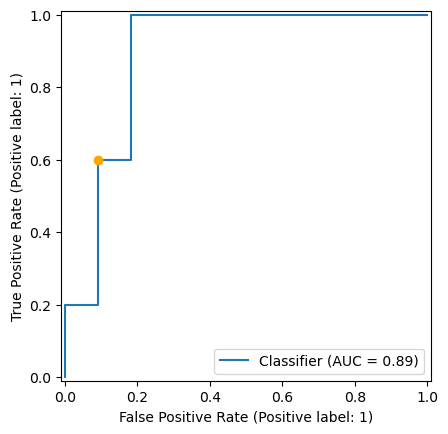

In [217]:
RocCurveDisplay.from_predictions(y_true, p_hat);
plt.gca().scatter(tfp, tvp, c="orange", zorder=10)

## Exercice 3

In [218]:
y_true = np.zeros(100)
y_true[9] = 1
p_hat = np.linspace(0.95, 0.05, 100)

In [219]:
y_true

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [220]:
p_hat

array([0.95      , 0.94090909, 0.93181818, 0.92272727, 0.91363636,
       0.90454545, 0.89545455, 0.88636364, 0.87727273, 0.86818182,
       0.85909091, 0.85      , 0.84090909, 0.83181818, 0.82272727,
       0.81363636, 0.80454545, 0.79545455, 0.78636364, 0.77727273,
       0.76818182, 0.75909091, 0.75      , 0.74090909, 0.73181818,
       0.72272727, 0.71363636, 0.70454545, 0.69545455, 0.68636364,
       0.67727273, 0.66818182, 0.65909091, 0.65      , 0.64090909,
       0.63181818, 0.62272727, 0.61363636, 0.60454545, 0.59545455,
       0.58636364, 0.57727273, 0.56818182, 0.55909091, 0.55      ,
       0.54090909, 0.53181818, 0.52272727, 0.51363636, 0.50454545,
       0.49545455, 0.48636364, 0.47727273, 0.46818182, 0.45909091,
       0.45      , 0.44090909, 0.43181818, 0.42272727, 0.41363636,
       0.40454545, 0.39545455, 0.38636364, 0.37727273, 0.36818182,
       0.35909091, 0.35      , 0.34090909, 0.33181818, 0.32272727,
       0.31363636, 0.30454545, 0.29545455, 0.28636364, 0.27727

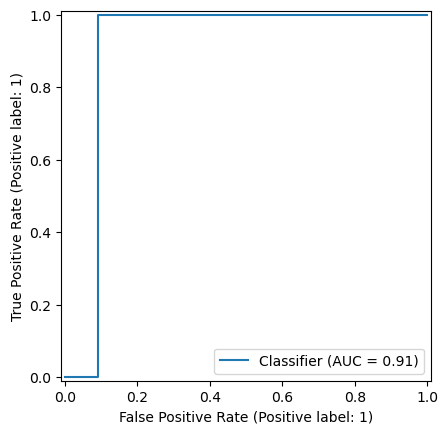

In [221]:
RocCurveDisplay.from_predictions(y_true, p_hat);

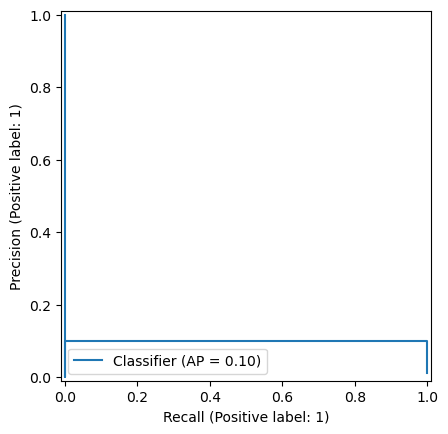

In [224]:
PrecisionRecallDisplay.from_predictions(y_true, p_hat);